# CSM Dataset Analysis Notebook

This Jupyter Notebook serves to provide analysis on data collected from LSF systems using CSM. Specifically, we are targeting the Lassen Supercomputer Job Dataset from the Livermore Archive for System Telemetry \(LAST\) (https://github.com/LLNL/LAST/tree/main).

There are three types of information that we extract and analyze in this notebook.

* General Statistics
* Node preference on Lassen
* Parameter correlation 

### 1. General Statistics
To begin analyzing a dataset, we first need to understand what we are working with from a fundamental level.

In [2]:
import numpy as np
import pandas as pd
from collections import Counter

from sklearn.cluster import KMeans

In [4]:
# paths for input files
ALLOC_PATH = "/home/j/Desktop/flux/sc25_poster/LAST/Lassen-Supercomputer-Job-Dataset/final_csm_allocation_history_hashed.csv"
NODE_PATH  = "/home/j/Desktop/flux/sc25_poster/LAST/Lassen-Supercomputer-Job-Dataset/final_csm_allocation_node_history.csv"

# Skip the first X jobs (by allocation_id order)
SKIP_JOBS = 10000 

# Load CSVs fully
alloc_df = pd.read_csv(
    ALLOC_PATH,
    dtype={"allocation_id": "Int64", "queue": "string"},
)

node_df = pd.read_csv(
    NODE_PATH,
    dtype={"allocation_id": "Int64"},
)

# Determine which allocation_ids to keep
unique_alloc_ids = alloc_df["allocation_id"].dropna().astype("int64").unique()
if SKIP_JOBS > 0:
    # Sort allocation IDs by order of appearance, then skip the first SKIP_JOBS
    keep_ids = set(unique_alloc_ids[SKIP_JOBS:])
else:
    keep_ids = set(unique_alloc_ids)

alloc_df = alloc_df[alloc_df["allocation_id"].isin(keep_ids)]
node_df = node_df[node_df["allocation_id"].isin(keep_ids)]

print(f"Skipped the first {SKIP_JOBS:,} jobs.")
print(f"Remaining allocations: {alloc_df['allocation_id'].nunique():,}")
print(f"Remaining node records: {len(node_df):,}")

# Stats check
node_alloc_ids = set(node_df["allocation_id"].dropna().astype("int64").unique())
alloc_ids = alloc_df["allocation_id"].dropna().astype("int64")

total_allocs = len(alloc_ids)
mask_missing = ~alloc_ids.isin(node_alloc_ids)
missing_count = mask_missing.sum()

by_queue_missing = Counter()
if "queue" in alloc_df.columns:
    by_queue_missing.update(
        alloc_df.loc[mask_missing, "queue"].fillna("<NA>").value_counts().to_dict()
    )

print(f"Total allocations scanned (after skip): {total_allocs:,}")
print(f"Allocations WITHOUT node history: {missing_count:,} "
      f"({missing_count/total_allocs:.2%} of jobs)")

if by_queue_missing:
    print("\nMissing-by-queue (top 10):")
    for q, c in by_queue_missing.most_common(10):
        print(f"  {q}: {c:,}")

alloc_df.head(), node_df.head()


/tmp/ipykernel_53549/2382138561.py:9: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  alloc_df = pd.read_csv(


Skipped the first 10,000 jobs.
Remaining allocations: 1,457,746
Remaining node records: 6,490,193
Total allocations scanned (after skip): 1,457,746
Allocations WITHOUT node history: 0 (0.00% of jobs)


(       Unnamed: 0  allocation_id  primary_job_id launch_node_name  \
 10000       10001          10792         13023.0        lassen710   
 10001       10002          10793         13024.0        lassen710   
 10002       10003          10794         13025.0        lassen710   
 10003       10004          10795         13026.0        lassen710   
 10004       10005          10796         13027.0        lassen710   
 
        isolated_cores user_flags  system_flags  ssd_min  ssd_max  num_nodes  \
 10000               0        NaN           NaN        0        0          1   
 10001               0       smt4           NaN        0        0          2   
 10002               0        NaN           NaN        0        0          1   
 10003               2        NaN           NaN        0        0          1   
 10004               0       smt4           NaN        0        0          8   
 
        ...              hashed_user_group_id                  begin_time  \
 10000  ...  8d0e44

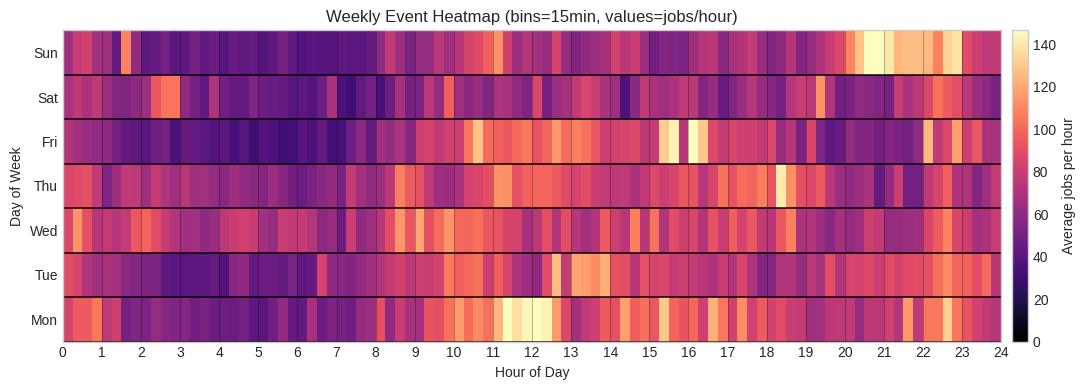

In [132]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_weekly_rate_from_events(
    events,                     # Path to CSV or DataFrame with a timestamp column
    time_col="timestamp",
    freq="15min",               # bin width (must divide 24h exactly)
    omit_zero_days=True,        # drop weekdays with zero total events
    cmap="magma",
    show_hour_lines=True,
    hour_line_width=0.4,
    hour_line_alpha=0.5,
    day_line_width=1.2,
    per_hour=True,              # True: jobs/hour, False: raw average count per bin
):
    """
    Render a weekly heatmap from events with timestamps, similar to the NHPP weekly rate plot.
    Returns the rate matrix as a DataFrame (rows=weekday, cols=hour-of-day bin starts).

    - events: str | pd.DataFrame
    - values are averaged over how many occurrences of each weekday are in the data window
    - per_hour=True -> normalize by bin_hours to show jobs/hour
    """
    # --- load ---
    if isinstance(events, (str, bytes)):
        df = pd.read_csv(events)
    else:
        df = events.copy()

    if time_col not in df.columns:
        raise ValueError(f"Column '{time_col}' not found in events.")

    t = pd.to_datetime(df[time_col], errors="coerce").dropna()
    if t.empty:
        print("No valid timestamps; nothing to plot.")
        return pd.DataFrame()

    df = pd.DataFrame({time_col: t})
    # derive weekday & time-of-day bin
    df["weekday"] = df[time_col].dt.dayofweek
    bin_minutes = int(pd.Timedelta(freq).total_seconds() // 60)
    if bin_minutes <= 0 or (1440 % bin_minutes) != 0:
        raise ValueError("freq must divide 24h exactly (e.g., 5min, 10min, 15min, 30min, 60min).")
    bins_per_day = 1440 // bin_minutes
    mins = df[time_col].dt.hour * 60 + df[time_col].dt.minute
    df["bin_idx"] = (mins // bin_minutes).astype(int)

    # counts per (weekday, bin)
    counts = df.groupby(["weekday", "bin_idx"]).size().rename("count").reset_index()

    # how many times each weekday appears in the covered date span?
    start_d = df[time_col].min().normalize()
    end_d   = df[time_col].max().normalize()
    all_days = pd.date_range(start_d, end_d, freq="D")
    weekday_occ = pd.Series(all_days.dayofweek).value_counts().reindex(range(7), fill_value=0)

    # optionally drop weekdays with zero total events
    totals = counts.groupby("weekday")["count"].sum()
    include_days = [d for d in range(7) if (totals.get(d, 0) > 0)] if omit_zero_days else list(range(7))
    if not include_days:
        print("No weekdays with events after filtering.")
        return pd.DataFrame()

    # complete grid
    grid = pd.MultiIndex.from_product([include_days, range(bins_per_day)],
                                      names=["weekday", "bin_idx"]).to_frame(index=False)
    counts_full = grid.merge(counts, on=["weekday", "bin_idx"], how="left").fillna({"count": 0})

    # average per occurrence of that weekday
    counts_full["occurs"] = counts_full["weekday"].map(weekday_occ).replace(0, np.nan)
    bin_hours = bin_minutes / 60.0
    if per_hour:
        # jobs / hour
        vals = counts_full["count"] / (counts_full["occurs"] * bin_hours)
    else:
        # average count per bin occurrence (not normalized to per-hour)
        vals = counts_full["count"] / counts_full["occurs"]
    counts_full["value"] = vals.fillna(0.0)

    # pivot to matrix (rows=weekday, cols=hour-of-day start)
    col_hour = (counts_full["bin_idx"] * bin_minutes) / 60.0
    counts_full = counts_full.assign(col_hour=col_hour)
    mat = counts_full.pivot(index="weekday", columns="col_hour", values="value")
    mat = mat.sort_index().sort_index(axis=1)

    # plot via pcolormesh (hour ticks, thicker day boundaries, optional hour lines)
    Z = mat.to_numpy()
    y_days = mat.index.to_list()
    x_edges = np.linspace(0.0, 24.0, bins_per_day + 1)
    y_edges = np.arange(len(y_days) + 1)
    X, Y = np.meshgrid(x_edges, y_edges)

    fig, ax = plt.subplots(figsize=(12, 4))

    # robust vmax for color stretch
    positive = Z[Z > 0]
    vmax = np.percentile(positive, 99.5) if positive.size else 1.0
    pcm = ax.pcolormesh(X, Y, Z, cmap=cmap, shading="flat", vmin=0, vmax=vmax)
    cbar = plt.colorbar(pcm, ax=ax, pad=0.01)
    cbar.set_label("Average jobs per hour" if per_hour else "Average jobs per bin")

    # hour ticks & limits
    ax.set_xticks(np.arange(0, 25, 1))
    ax.set_xlim(0, 24)

    # weekday labels
    day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    ax.set_yticks(np.arange(len(y_days)) + 0.5)
    ax.set_yticklabels([day_names[d] for d in y_days])

    # remove default grid
    ax.grid(False)

    # thicker horizontal day lines
    for y in range(len(y_days) + 1):
        ax.hlines(y, 0, 24, colors="black", linewidth=day_line_width, alpha=0.9)

    # faint vertical hour lines
    if show_hour_lines:
        for x in np.arange(0, 25, 1):
            ax.vlines(x, 0, len(y_days), colors="black",
                      linewidth=hour_line_width, alpha=hour_line_alpha)

    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Day of Week")
    ttl_unit = "jobs/hour" if per_hour else "avg jobs/bin"
    ax.set_title(f"Weekly Event Heatmap (bins={freq}, values={ttl_unit})")
    plt.tight_layout()
    plt.show()

    return mat
mat = plot_weekly_rate_from_events("events.csv", time_col="timestamp",
                                   freq="15min", omit_zero_days=True)

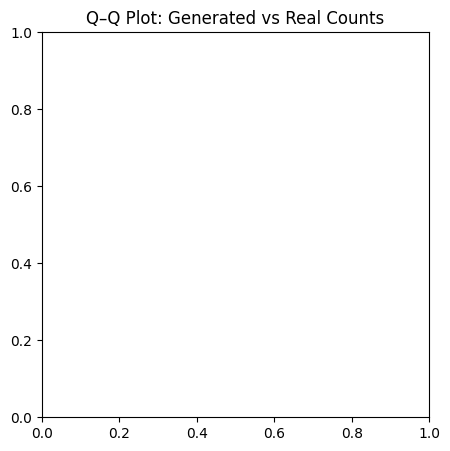

In [4]:
import scipy.stats as st
import numpy as np
import matplotlib.pyplot as plt

real_df = alloc_df
gen_df = pd.read_csv("events.csv")
real_counts = real_df.set_index(pd.to_datetime(real_df["job_submit_time"])).resample("1h").size()
gen_counts  = gen_df.set_index(pd.to_datetime(gen_df["timestamp"])).resample("1h").size()

# Align and remove empty bins
both = pd.concat([real_counts, gen_counts], axis=1, join="inner").dropna()
real, gen = both.iloc[:,0], both.iloc[:,1]

plt.figure(figsize=(5,5))
st.probplot(gen, dist=st.poisson(np.mean(real)), plot=plt)  # or use np.sort(gen) vs np.sort(real)
plt.title("Q–Q Plot: Generated vs Real Counts")
plt.show()

<Axes: xlabel='hour'>

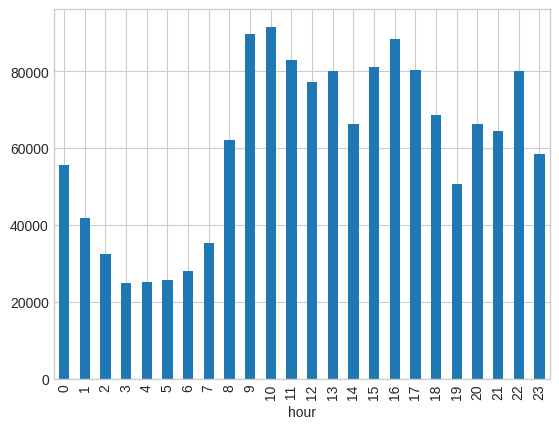

In [107]:
alloc_df["hour"] = pd.to_datetime(alloc_df["job_submit_time"]).dt.hour
alloc_df.groupby("hour").size().plot(kind="bar")

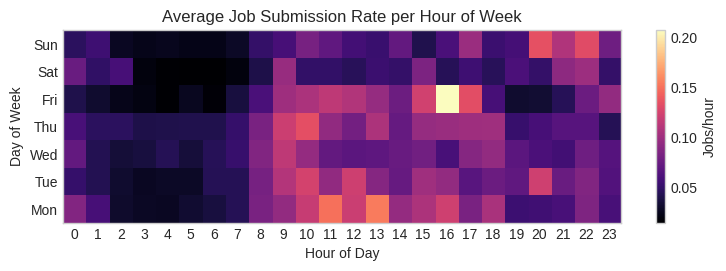

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
weekday,,,,,,,,,,,,,,,,,,,,,
0,0.086722,0.058369,0.030427,0.027176,0.026851,0.032068,0.036124,0.043500,0.082503,0.094462,...,0.095461,0.106413,0.121986,0.081969,0.104880,0.053446,0.055103,0.059337,0.084307,0.058826
1,0.050884,0.042680,0.031309,0.026472,0.028082,0.027803,0.043067,0.043423,0.080537,0.109664,...,0.072960,0.100043,0.094354,0.066589,0.075491,0.070026,0.122598,0.074755,0.085863,0.063493
2,0.071566,0.042115,0.034421,0.036789,0.043028,0.034761,0.044058,0.051720,0.086389,0.114850,...,0.073772,0.078718,0.059375,0.088309,0.094091,0.068153,0.060699,0.055714,0.077263,0.065080
3,0.059066,0.045954,0.046302,0.039646,0.040350,0.040845,0.040760,0.050753,0.082565,0.120941,...,0.072874,0.096204,0.097357,0.099679,0.100143,0.051473,0.058261,0.065459,0.066110,0.042966
4,0.040242,0.031000,0.023499,0.020690,0.015450,0.025907,0.016603,0.036681,0.059809,0.099857,...,0.076613,0.122985,0.206943,0.132606,0.058315,0.031185,0.032958,0.043841,0.075313,0.094269
5,0.075096,0.048663,0.058447,0.019281,0.015326,0.014397,0.014211,0.019026,0.039382,0.096684,...,0.050211,0.083486,0.044166,0.054360,0.044630,0.060722,0.050002,0.092256,0.099215,0.050087
6,0.046310,0.054290,0.026294,0.023639,0.025187,0.022981,0.023159,0.028500,0.050103,0.058199,...,0.071806,0.040745,0.059515,0.098456,0.052998,0.057820,0.134417,0.108062,0.131608,0.077147


In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def estimate_weekly_rate(alloc_df, time_col="job_submit_time", freq="1H"):
    df = alloc_df.copy()
    t = pd.to_datetime(df[time_col], errors="coerce")
    df["weekday"] = t.dt.dayofweek  # 0=Monday
    df["hour"] = t.dt.hour

    # 7×24 grid of job submissions
    rate = df.groupby(["weekday", "hour"]).size().unstack(fill_value=0)
    rate = rate / (df[time_col].nunique() / 7)  # normalize by # of weeks if needed

    plt.figure(figsize=(9,2.5))
    plt.imshow(rate, aspect="auto", cmap="magma", origin="lower")
    plt.yticks(range(7), ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
    plt.xticks(range(0,24))
    plt.grid(False)
    plt.xlabel("Hour of Day")
    plt.ylabel("Day of Week")
    plt.title("Average Job Submission Rate per Hour of Week")
    plt.colorbar(label="Jobs/hour")
    plt.show()

    return rate

estimate_weekly_rate(alloc_df)

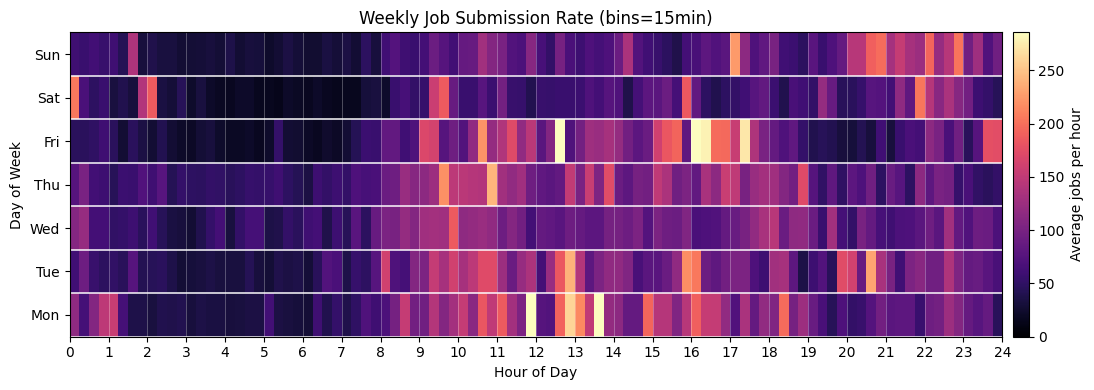

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_weekly_rate_heatmap(
    alloc_df,
    time_col="job_submit_time",
    freq="15min",
    omit_zero_days=True,
    cmap="magma",
):
    """
    Plot a weekly NHPP-style rate heatmap with minute granularity bins and hour x-axis.

    Parameters
    ----------
    alloc_df : pd.DataFrame
        Must have a datetime-like column `time_col` with job submission timestamps.
    time_col : str
        Name of the timestamp column in alloc_df.
    freq : str
        Bin width for time-of-day (e.g., '5min', '10min', '15min', '30min', '1H').
    omit_zero_days : bool
        If True, drop weekdays with zero total jobs across the entire dataset.
    cmap : str
        Matplotlib colormap name.

    Returns
    -------
    rate_df : pd.DataFrame
        Index = included weekdays (0=Mon,...,6=Sun),
        Columns = bin start times (hours as float),
        Values = jobs per hour.
    """
    # --- Parse times ---
    t = pd.to_datetime(alloc_df[time_col], errors="coerce")
    df = pd.DataFrame({time_col: t}).dropna()
    if df.empty:
        print("No valid timestamps to plot.")
        return pd.DataFrame()

    df["weekday"] = df[time_col].dt.dayofweek  # 0=Mon ... 6=Sun
    # minutes since midnight
    mins = df[time_col].dt.hour * 60 + df[time_col].dt.minute
    # bin size in minutes
    bin_minutes = int(pd.Timedelta(freq).total_seconds() // 60)
    if bin_minutes <= 0 or (1440 % bin_minutes) != 0:
        raise ValueError("freq must divide 24h exactly (e.g., 5min, 10min, 15min, 30min, 60min).")
    bins_per_day = 1440 // bin_minutes
    df["bin_idx"] = (mins // bin_minutes).astype(int)

    # --- Count events per (weekday, bin) ---
    counts = df.groupby(["weekday", "bin_idx"]).size().rename("count").reset_index()

    # --- How many occurrences of each weekday in the dataset? ---
    # This makes the rate truly "per hour" averaged across the actual number of Mondays, Tuesdays, etc.
    date_min = df[time_col].dt.normalize().min()
    date_max = df[time_col].dt.normalize().max()
    all_days = pd.date_range(date_min, date_max, freq="D")
    weekday_occurrences = pd.Series(all_days.dayofweek).value_counts().reindex(range(7), fill_value=0)

    # --- Build a complete grid for included weekdays ---
    # Optionally omit weekdays with zero jobs across the whole dataset
    day_totals = counts.groupby("weekday")["count"].sum()
    if omit_zero_days:
        include_days = [d for d in range(7) if day_totals.get(d, 0) > 0]
    else:
        include_days = list(range(7))

    if not include_days:
        print("No weekdays with jobs (after applying omit_zero_days=True).")
        return pd.DataFrame()

    grid = (
        pd.MultiIndex.from_product([include_days, range(bins_per_day)],
                                   names=["weekday", "bin_idx"])
        .to_frame(index=False)
    )
    counts_full = grid.merge(counts, on=["weekday", "bin_idx"], how="left").fillna({"count": 0})

    # --- Convert counts to jobs/hour ---
    bin_hours = bin_minutes / 60.0
    # divide by how many occurrences of that weekday we observed (avoid division by zero)
    counts_full["occurs"] = counts_full["weekday"].map(weekday_occurrences).replace(0, np.nan)
    counts_full["rate_jobs_per_hr"] = counts_full["count"] / (counts_full["occurs"] * bin_hours)
    counts_full["rate_jobs_per_hr"] = counts_full["rate_jobs_per_hr"].fillna(0.0)

    # --- Make a pivot: rows=weekday, cols=time-of-day (in hours, start of bin) ---
    # Column labels in hours so x-axis is in hours even if bins are minutes
    col_hours = (counts_full["bin_idx"] * bin_minutes) / 60.0  # 0 .. <24 by step=bin_hours
    counts_full = counts_full.assign(col_hour=col_hours)
    rate_df = counts_full.pivot(index="weekday", columns="col_hour", values="rate_jobs_per_hr")
    rate_df = rate_df.sort_index().sort_index(axis=1)

    # --- Plot with day boundary lines (no grid) ---
    Z = rate_df.to_numpy()
    y_days = rate_df.index.to_list()  # included weekday numbers
    # Build edges for pcolormesh
    x_edges = np.linspace(0.0, 24.0, bins_per_day + 1)
    y_edges = np.arange(len(y_days) + 1)

    fig, ax = plt.subplots(figsize=(12, 4))
    # pcolormesh wants 2D edges
    X, Y = np.meshgrid(x_edges, y_edges)

    # Use a small floor vmax to avoid flat color if very low activity
    vmax = np.percentile(Z[Z > 0], 99.5) if np.any(Z > 0) else 1.0
    pcm = ax.pcolormesh(X, Y, Z, cmap=cmap, shading="flat", vmin=0, vmax=vmax)

    cbar = plt.colorbar(pcm, ax=ax, pad=0.01)
    cbar.set_label("Average jobs per hour")

    # X ticks every hour
    ax.set_xticks(np.arange(0, 25, 1))
    ax.set_xlim(0, 24)

    # Replace y ticks with weekday names
    day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    ax.set_yticks(np.arange(len(y_days)) + 0.5)
    ax.set_yticklabels([day_names[d] for d in y_days])

    # Remove standard grid
    ax.grid(False)

    # === custom boundary lines ===
    # thicker horizontal lines between days
    for y in range(len(y_days) + 1):
        ax.hlines(y, 0, 24, colors="white", linewidth=1.2, alpha=0.9)

    # faint vertical lines at each hour
    for x in np.arange(0, 25, 1):
        ax.vlines(x, 0, len(y_days), colors="white", linewidth=0.4, alpha=0.5, linestyles="-")

    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Day of Week")
    ax.set_title(f"Weekly Job Submission Rate (bins={freq})")
    plt.tight_layout()
    plt.show()

    return rate_df
# 15-minute bins, omit days with zero total jobs
rate = plot_weekly_rate_heatmap(alloc_df, time_col="job_submit_time", freq="15min", omit_zero_days=True)

# 5-minute bins, keep all weekdays
# rate_5m = plot_weekly_rate_heatmap(alloc_df, freq="0.1min", omit_zero_days=False)


In [123]:
import pandas as pd

def summarize_job_time_range(alloc_df, submit_col="submit_time"):
    # Convert timestamps if needed
    times = pd.to_datetime(alloc_df[submit_col], errors="coerce").dropna().sort_values()
    start, end = times.min(), times.max()

    # Make a full daily range and mark missing days
    full_days = pd.date_range(start=start.floor("D"), end=end.floor("D"), freq="D")
    job_days = times.dt.floor("D").unique()
    missing_days = full_days.difference(job_days)

    print("=== Job Time Range Summary ===")
    print(f"Start:  {start}")
    print(f"End:    {end}")
    print(f"Span:   {(end - start).days} days")
    print(f"Total days with jobs: {len(job_days)}")
    print(f"Days with no jobs:    {len(missing_days)}")

    if len(missing_days) > 0:
        print("\nExample gaps:")
        for g in pd.Series(missing_days).sort_values().to_list()[:10]:
            print(f"  {g.date()}")

    return {
        "start": start,
        "end": end,
        "full_days": full_days,
        "job_days": job_days,
        "missing_days": missing_days,
    }

# Example usage
info = summarize_job_time_range(alloc_df, "begin_time")


=== Job Time Range Summary ===
Start:  2018-11-28 09:42:53.681304
End:    2020-11-18 10:06:21.224607
Span:   721 days
Total days with jobs: 721
Days with no jobs:    1

Example gaps:
  2019-10-05


In [9]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

# --- assumes alloc_df already loaded and filtered (e.g., SKIP_JOBS applied) ---
# and that it has columns: allocation_id, num_nodes, begin_time, end_time

# Compute runtime and node-hours
t0 = pd.to_datetime(alloc_df["begin_time"], errors="coerce")
t1 = pd.to_datetime(alloc_df["end_time"], errors="coerce")
alloc_df["runtime_hours"] = (t1 - t0).dt.total_seconds() / 3600.0

alloc_df["num_nodes"] = pd.to_numeric(alloc_df["num_nodes"], errors="coerce")
alloc_df["runtime_hours"] = pd.to_numeric(alloc_df["runtime_hours"], errors="coerce")
alloc_df["node_hours"] = alloc_df["num_nodes"].fillna(0) * alloc_df["runtime_hours"].fillna(0)

# Keep valid rows
eps = 1e-9
mask = (alloc_df["num_nodes"] > 0) & (alloc_df["runtime_hours"] > 0) & np.isfinite(alloc_df["node_hours"])
work = alloc_df.loc[mask, ["allocation_id", "num_nodes", "runtime_hours", "node_hours"]].copy()

# --- Build orthogonal log-space features ---
ln_n = np.log10(work["num_nodes"].to_numpy())
ln_t = np.log10(work["runtime_hours"].to_numpy())

# u ~ log area, v ~ log shape
inv_sqrt2 = 1.0 / np.sqrt(2.0)
u = (ln_n + ln_t) * inv_sqrt2          # total load (log area)
v = (ln_n - ln_t) * inv_sqrt2          # shape: +wide/short, -tall/long

# --- 1) Cluster u into S/M/L/XL (load classes) ---
k_area = 4
km_area = KMeans(n_clusters=k_area, random_state=42, n_init=10)
labels_area = km_area.fit_predict(u.reshape(-1, 1))

centers_u = km_area.cluster_centers_.ravel()
order_u = np.argsort(centers_u)  # ascending load
area_names = ["S", "M", "L", "XL"]
area_map = {order_u[i]: area_names[i] for i in range(k_area)}

work["size_bin_area"] = [area_map[l] for l in labels_area]

# Optional: recover center (node-hours) for each area bin
# u ≈ (log10(node_hours)) / sqrt(2) + const, but we can estimate directly from data:
# A simple proxy is the median node_hours per bin.
area_centers = (work.groupby("size_bin_area")["node_hours"]
                   .median()
                   .reindex(area_names))

# --- 2) Bin v into shape classes (burst/balanced/marathon) ---
# Option A: quantile-based (simple, robust)
q1, q2 = np.quantile(v, [1/3, 2/3])
def shape_from_v(x):
    if x >= q2:   return "burst"      # many nodes, short time
    if x <= q1:   return "marathon"   # few nodes, long time
    return "balanced"

work["shape_bin"] = [shape_from_v(x) for x in v]

# (Option B: clustering in 1D on v if you prefer)
# km_shape = KMeans(n_clusters=3, random_state=42, n_init=10).fit(v.reshape(-1,1))
# centers_v = km_shape.cluster_centers_.ravel()
# order_v = np.argsort(centers_v)
# shape_names = ["marathon", "balanced", "burst"]
# shape_map = {order_v[i]: shape_names[i] for i in range(3)}
# work["shape_bin"] = [shape_map[l] for l in km_shape.labels_]

# --- Attach back to alloc_df ---
alloc_df["size_bin_area"] = pd.NA
alloc_df["shape_bin"] = pd.NA
alloc_df.loc[work.index, "size_bin_area"] = work["size_bin_area"]
alloc_df.loc[work.index, "shape_bin"] = work["shape_bin"]

# --- Summaries ---
summary_area = (work.groupby("size_bin_area")
                    .agg(jobs=("allocation_id","count"),
                         total_node_hours=("node_hours","sum"),
                         median_node_hours=("node_hours","median"))
                    .reindex(area_names))
print("=== Area (load) bins ===")
print(summary_area)

summary_shape = work["shape_bin"].value_counts()
print("\n=== Shape bins (counts) ===")
print(summary_shape)

# Cross-tab to see composition
crosstab = pd.crosstab(work["size_bin_area"], work["shape_bin"])
print("\n=== Area x Shape ===")
print(crosstab)


=== Area (load) bins ===
                 jobs  total_node_hours  median_node_hours
size_bin_area                                             
S              358939      3.738656e+03           0.007458
M              424545      4.230942e+04           0.077009
L              386640      5.792287e+05           1.111304
XL             287603      1.024432e+07          12.008631

=== Shape bins (counts) ===
shape_bin
balanced    485909
burst       485909
marathon    485909
Name: count, dtype: int64

=== Area x Shape ===
shape_bin      balanced   burst  marathon
size_bin_area                            
L                134829   22395    229416
M                233386  178370     12789
S                 78631  280308         0
XL                39063    4836    243704


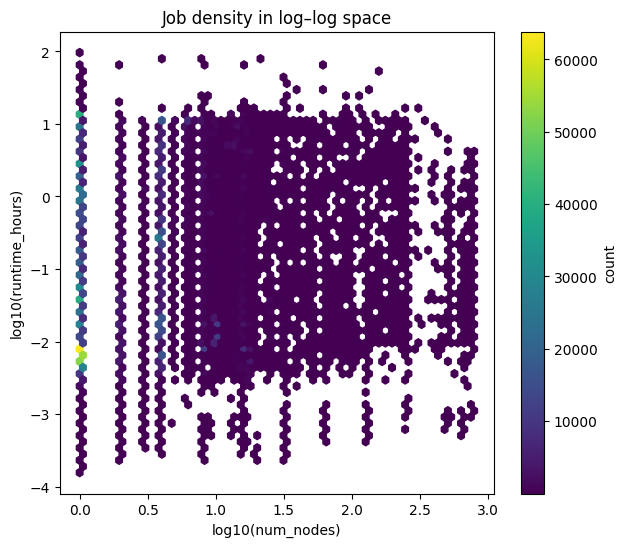

In [12]:
import numpy as np
import matplotlib.pyplot as plt

mask = (alloc_df["num_nodes"] > 0) & (alloc_df["runtime_hours"] > 0)
x = np.log10(alloc_df.loc[mask, "num_nodes"])
y = np.log10(alloc_df.loc[mask, "runtime_hours"])

plt.figure(figsize=(7,6))
hb = plt.hexbin(x, y, gridsize=60, mincnt=1)
plt.xlabel("log10(num_nodes)")
plt.ylabel("log10(runtime_hours)")
plt.title("Job density in log–log space")
cb = plt.colorbar(hb)
cb.set_label("count")
plt.show()


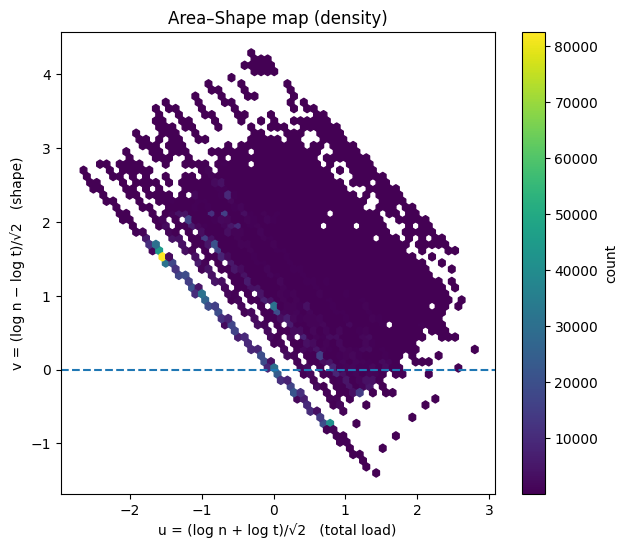

In [13]:
m2 = (alloc_df["num_nodes"] > 0) & (alloc_df["runtime_hours"] > 0)
ln_n = np.log10(alloc_df.loc[m2, "num_nodes"].to_numpy())
ln_t = np.log10(alloc_df.loc[m2, "runtime_hours"].to_numpy())
inv_sqrt2 = 1.0 / np.sqrt(2.0)
u = (ln_n + ln_t) * inv_sqrt2   # area axis
v = (ln_n - ln_t) * inv_sqrt2   # shape axis

plt.figure(figsize=(7,6))
hb = plt.hexbin(u, v, gridsize=60, mincnt=1)
plt.axhline(0, linestyle="--")
plt.xlabel("u = (log n + log t)/√2   (total load)")
plt.ylabel("v = (log n − log t)/√2   (shape)")
plt.title("Area–Shape map (density)")
cb = plt.colorbar(hb)
cb.set_label("count")
plt.show()


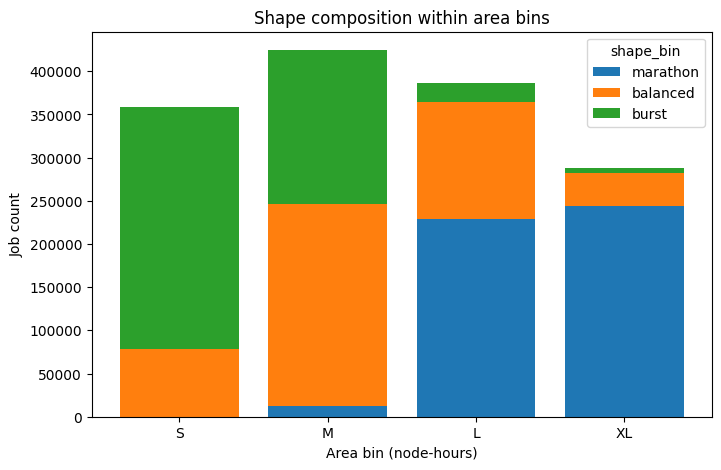

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

area_order = ["S","M","L","XL"]
shape_order = ["marathon", "balanced", "burst"]

tbl = (pd.crosstab(alloc_df["size_bin_area"], alloc_df["shape_bin"])
         .reindex(index=area_order, columns=shape_order, fill_value=0))

# Stacked bars
plt.figure(figsize=(8,5))
bottom = None
for col in tbl.columns:
    vals = tbl[col].values
    plt.bar(tbl.index, vals, bottom=bottom, label=col)
    bottom = vals if bottom is None else bottom + vals

plt.xlabel("Area bin (node-hours)")
plt.ylabel("Job count")
plt.title("Shape composition within area bins")
plt.legend(title="shape_bin")
plt.show()


In [15]:
import numpy as np
import pandas as pd

m = (alloc_df["num_nodes"] > 0) & (alloc_df["runtime_hours"] > 0)
g = alloc_df.loc[m].groupby(["size_bin_area","shape_bin"]).agg(
    jobs=("allocation_id","count"),
    med_nodes=("num_nodes","median"),
    med_runtime_hr=("runtime_hours","median"),
    med_node_hours=("node_hours","median"),
)
print(g.sort_index())


                           jobs  med_nodes  med_runtime_hr  med_node_hours
size_bin_area shape_bin                                                   
L             balanced   134829        4.0        0.269478        1.091462
              burst       22395       16.0        0.039767        0.766456
              marathon   229416        1.0        1.068482        1.186757
M             balanced   233386        1.0        0.055834        0.068416
              burst      178370        4.0        0.014560        0.081829
              marathon    12789        1.0        0.264362        0.264362
S             balanced    78631        1.0        0.016689        0.016689
              burst      280308        1.0        0.006104        0.006647
XL            balanced    39063       16.0        1.272957       14.250776
              burst        4836      128.0        0.171508       15.625838
              marathon   243704        4.0        8.006702       12.006462


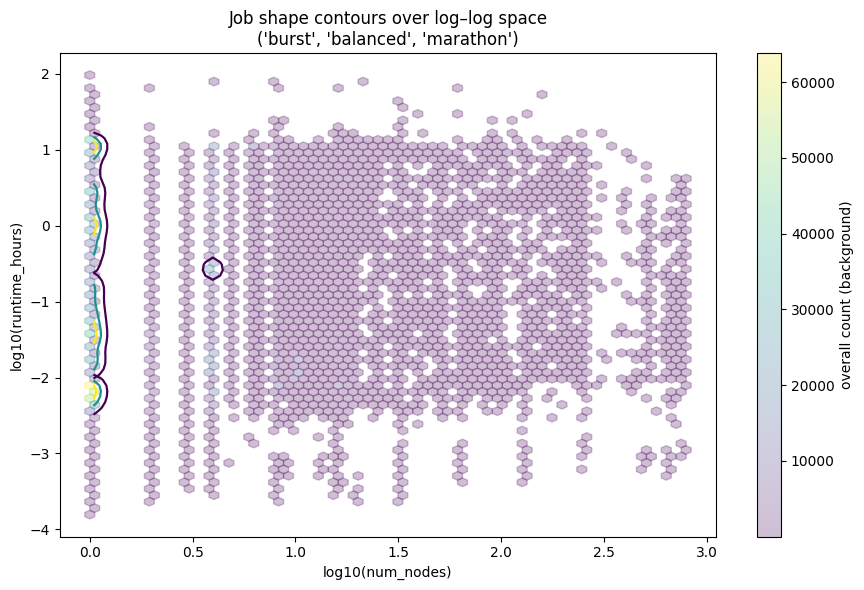

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter  # pip install scipy if needed

# assumes alloc_df has: num_nodes, runtime_hours, shape_bin

valid = (
    (alloc_df["num_nodes"] > 0) &
    (alloc_df["runtime_hours"] > 0) &
    (alloc_df["shape_bin"].notna())
)
dfv = alloc_df.loc[valid, ["num_nodes", "runtime_hours", "shape_bin"]].copy()
dfv["log_n"] = np.log10(dfv["num_nodes"].to_numpy())
dfv["log_t"] = np.log10(dfv["runtime_hours"].to_numpy())

# coarser grid -> fewer empty cells; tweak as needed
xbins = 80
ybins = 80
xmin, xmax = dfv["log_n"].min(), dfv["log_n"].max()
ymin, ymax = dfv["log_t"].min(), dfv["log_t"].max()
xedges = np.linspace(xmin, xmax, xbins + 1)
yedges = np.linspace(ymin, ymax, ybins + 1)
xcenters = 0.5 * (xedges[:-1] + xedges[1:])
ycenters = 0.5 * (yedges[:-1] + yedges[1:])
X, Y = np.meshgrid(xcenters, ycenters, indexing="xy")

def density_for(shape_name, sigma=1.0):
    s = dfv[dfv["shape_bin"] == shape_name]
    H, _, _ = np.histogram2d(s["log_n"], s["log_t"], bins=[xedges, yedges])
    H = H.T  # rows=y, cols=x
    if sigma and sigma > 0:
        H = gaussian_filter(H, sigma=sigma, mode="nearest")
    Hmax = H.max() if H.max() > 0 else 1.0
    return H / Hmax, H

shapes = ["burst", "balanced", "marathon"]
dens_norm = {}
dens_raw = {}
for name in shapes:
    dn, dr = density_for(name, sigma=1.2)  # gentle smooth
    dens_norm[name] = dn
    dens_raw[name]  = dr

# slightly lower/fewer levels so contours are larger/easier to label
levels = [0.2, 0.5, 0.8]

plt.figure(figsize=(9, 6))

# background overall density
plt.hexbin(dfv["log_n"], dfv["log_t"], gridsize=60, mincnt=1, alpha=0.25)
cb = plt.colorbar()
cb.set_label("overall count (background)")

# overlay contours + force labels at each class peak
for name in shapes:
    CS = plt.contour(X, Y, dens_norm[name], levels=levels, linewidths=1.6)
    # place a label at the global maximum of this class’s (smoothed) density
    iy, ix = np.unravel_index(dens_norm[name].argmax(), dens_norm[name].shape)
    px, py = X[iy, ix], Y[iy, ix]
    # draw a small white box behind text to ensure readability
    # plt.text(px, py, name, fontsize=10, ha="center", va="center",
    #          bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.8))

plt.xlabel("log10(num_nodes)")
plt.ylabel("log10(runtime_hours)")
plt.title("Job shape contours over log–log space\n('burst', 'balanced', 'marathon')")
plt.tight_layout()
plt.show()


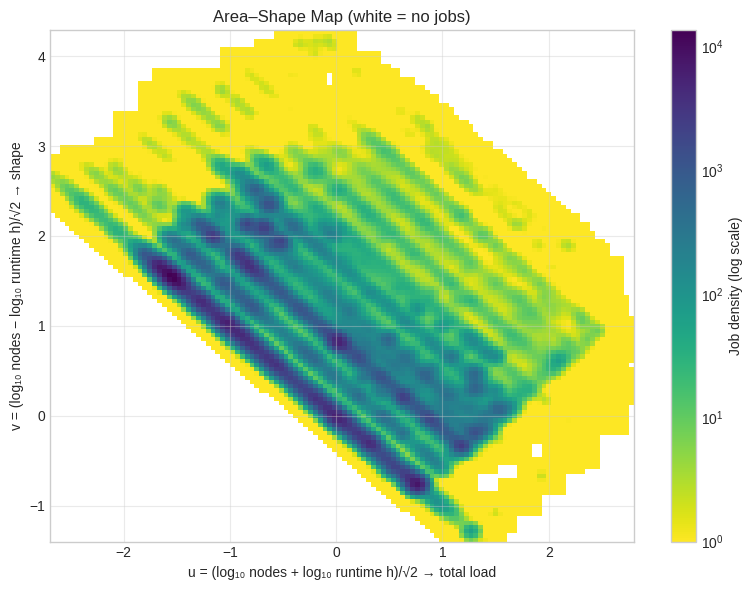

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

plt.style.use("seaborn-v0_8-whitegrid")  # light grid background

valid = (
    (alloc_df["num_nodes"] > 0) &
    (alloc_df["runtime_hours"] > 0)
)
dfv = alloc_df.loc[valid, ["num_nodes", "runtime_hours"]].copy()
ln_n = np.log10(dfv["num_nodes"].to_numpy())
ln_t = np.log10(dfv["runtime_hours"].to_numpy())

# derive u,v coordinates
inv_sqrt2 = 1.0 / np.sqrt(2.0)
u = (ln_n + ln_t) * inv_sqrt2
v = (ln_n - ln_t) * inv_sqrt2
dfv["u"] = u
dfv["v"] = v

# compute density grid
xbins, ybins = 120, 120
xmin, xmax = u.min(), u.max()
ymin, ymax = v.min(), v.max()
xedges = np.linspace(xmin, xmax, xbins + 1)
yedges = np.linspace(ymin, ymax, ybins + 1)
H, _, _ = np.histogram2d(u, v, bins=[xedges, yedges])
H = gaussian_filter(H.T, sigma=1.0, mode="nearest")

# example jobs
examples = [
    ("1 node \n× 1 h", 1, 1),
    ("16 nodes \n× 10 min", 16, 10/60),
    ("64 nodes \n× 1 h", 64, 1),
    ("256 nodes \n× 8 h", 256, 8),
    ("1024 nodes \n× 30 min", 1024, 0.5),
    ("1 nodes \n× 24 seconds", 1, 0.4/60),
    ("1024 nodes \n× 1 min", 1024, 0.05/60),
    ("2 nodes \n× 2 hours", 2, 2),
    ("1 node \n× 12 hours", 1, 12),


]

def to_uv(nodes, hours):
    ln_n = np.log10(nodes)
    ln_t = np.log10(hours)
    return (ln_n + ln_t) * inv_sqrt2, (ln_n - ln_t) * inv_sqrt2

# --- plot ---
import matplotlib.colors as mcolors

# Mask zeros so they appear white
H_masked = np.ma.masked_where(H <= 0, H)

# Create a copy of the colormap with white for masked areas
cmap = plt.cm.viridis_r
cmap.set_bad(color="white")

# Optional: use log scale for better contrast
norm = mcolors.LogNorm(vmin=1, vmax=H.max())

# --- plot ---
fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(H_masked, origin="lower", extent=(xmin,xmax,ymin,ymax),
               aspect="auto", cmap=cmap, norm=norm)

cb = plt.colorbar(im, ax=ax)
cb.set_label("Job density (log scale)")

ax.set_xlabel("u = (log₁₀ nodes + log₁₀ runtime h)/√2 → total load")
ax.set_ylabel("v = (log₁₀ nodes − log₁₀ runtime h)/√2 → shape")
ax.set_title("Area–Shape Map (white = no jobs)")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


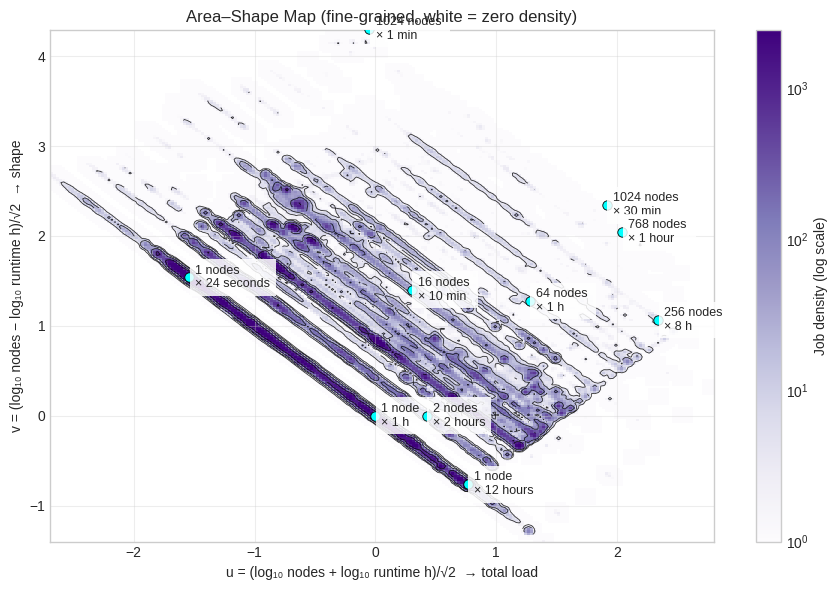

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import matplotlib.colors as mcolors

# --- data prep (assumes alloc_df exists with num_nodes, runtime_hours) ---
valid = (alloc_df["num_nodes"] > 0) & (alloc_df["runtime_hours"] > 0)
df = alloc_df.loc[valid, ["num_nodes", "runtime_hours"]].copy()
ln_n = np.log10(df["num_nodes"].to_numpy())
ln_t = np.log10(df["runtime_hours"].to_numpy())

# area-shape transform
inv_sqrt2 = 1.0 / np.sqrt(2.0)
u = (ln_n + ln_t) * inv_sqrt2
v = (ln_n - ln_t) * inv_sqrt2

# --- fine-grained grid + gentle smoothing ---
xbins, ybins = 220, 220           # finer grid (tune as desired)
xmin, xmax = u.min(), u.max()
ymin, ymax = v.min(), v.max()
xedges = np.linspace(xmin, xmax, xbins + 1)
yedges = np.linspace(ymin, ymax, ybins + 1)

H, _, _ = np.histogram2d(u, v, bins=[xedges, yedges])
H = H.T  # rows=y, cols=x

# light smoothing: preserves detail but helps contours
sigma = 0.7
H_smooth = gaussian_filter(H, sigma=sigma, mode="nearest")

# mask zeros -> white; log scale for dynamic range
H_masked = np.ma.masked_where(H_smooth <= 0, H_smooth)

# make a copy of the colormap so global state isn't changed
cmap = plt.cm.Purples.copy()
cmap.set_bad(color="white")

# robust upper cap so a few super-hot bins don't wash out the rest
vmax = np.percentile(H_smooth[H_smooth > 0], 99.5) if np.any(H_smooth > 0) else 1.0
norm = mcolors.LogNorm(vmin=1, vmax=vmax)

# centers for contours
xcenters = 0.5 * (xedges[:-1] + xedges[1:])
ycenters = 0.5 * (yedges[:-1] + yedges[1:])
X, Y = np.meshgrid(xcenters, ycenters, indexing="xy")

# --- example points to overlay (nodes, hours) ---
examples = [
    ("1 node \n× 1 h", 1, 1),
    ("16 nodes \n× 10 min", 16, 10/60),
    ("64 nodes \n× 1 h", 64, 1),
    ("256 nodes \n× 8 h", 256, 8),
    ("1024 nodes \n× 30 min", 1024, 0.5),
    ("1 nodes \n× 24 seconds", 1, 0.4/60),
    ("1024 nodes \n× 1 min", 1024, 0.05/60),
    ("2 nodes \n× 2 hours", 2, 2),
    ("1 node \n× 12 hours", 1, 12),
    ("768 nodes \n× 1 hour", 768, 1),
]
def to_uv(nodes, hours):
    ln_n = np.log10(nodes); ln_t = np.log10(hours)
    return (ln_n + ln_t) * inv_sqrt2, (ln_n - ln_t) * inv_sqrt2

# --- plot ---
fig, ax = plt.subplots(figsize=(9, 6))

im = ax.imshow(
    H_masked, origin="lower", extent=(xmin, xmax, ymin, ymax),
    aspect="auto", cmap=cmap, norm=norm, interpolation="nearest"
)
cb = plt.colorbar(im, ax=ax)
cb.set_label("Job density (log scale)")

# contours over the same field (use normalized levels for a consistent look)
# choose a few levels so lines are visible but not cluttered
levels = mcolors.LogNorm(vmin=1, vmax=vmax).inverse([0.15, 0.35, 0.6, 0.85])
CS = ax.contour(X, Y, H_smooth, levels=levels, colors="k", linewidths=0.6, alpha=0.8)
ax.clabel(CS, inline=True, fontsize=8, fmt=" ")

# overlay example markers
for label, nodes, hrs in examples:
    ux, vy = to_uv(nodes, hrs)
    ax.scatter(ux, vy, s=46, c="cyan", edgecolors="black", linewidths=0.6, zorder=3)
    ax.text(ux + 0.05, vy, label, fontsize=9, va="center", ha="left",
            bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"))

ax.set_xlabel("u = (log₁₀ nodes + log₁₀ runtime h)/√2  → total load")
ax.set_ylabel("v = (log₁₀ nodes − log₁₀ runtime h)/√2  → shape")
ax.set_title("Area–Shape Map (fine-grained, white = zero density)")
ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()


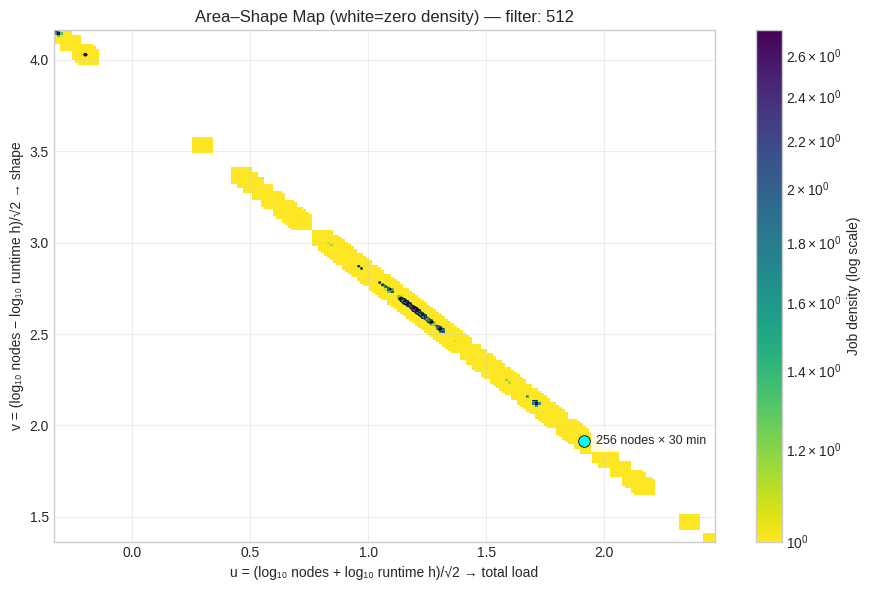

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import matplotlib.colors as mcolors

def plot_area_shape_map(
    alloc_df,
    node_filter=None,
    examples=None,
    xbins=220,
    ybins=220,
    sigma=0.7,
):
    """
    Plot a fine-grained area-shape map for jobs in alloc_df.

    Parameters
    ----------
    alloc_df : pd.DataFrame with ["num_nodes", "runtime_hours"]
    node_filter : int | list[int] | None
        If given, include only jobs with exactly this node count (or in this list).
    examples : list[(label:str, nodes:int, runtime_hours:float)]
    xbins, ybins : int
    sigma : float  (Gaussian smoothing for visuals)
    """
    valid = (alloc_df["num_nodes"] > 0) & (alloc_df["runtime_hours"] > 0)
    df = alloc_df.loc[valid, ["num_nodes", "runtime_hours"]].copy()

    # Filter by node count(s) if requested
    if node_filter is not None:
        if np.isscalar(node_filter):
            df = df[df["num_nodes"] == node_filter]
        else:
            df = df[df["num_nodes"].isin(node_filter)]

    if df.empty:
        print("No jobs match the given filter.")
        return

    # Transform to area–shape coordinates
    inv_sqrt2 = 1.0 / np.sqrt(2.0)
    ln_n = np.log10(df["num_nodes"].to_numpy())
    ln_t = np.log10(df["runtime_hours"].to_numpy())
    u = (ln_n + ln_t) * inv_sqrt2
    v = (ln_n - ln_t) * inv_sqrt2

    xmin, xmax = u.min(), u.max()
    ymin, ymax = v.min(), v.max()

    # If extremely sparse (<= 5 points), just scatter for clarity
    if len(u) <= 5:
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.scatter(u, v, s=60, c="tab:blue", edgecolors="black")
        ax.set_xlabel("u = (log₁₀ nodes + log₁₀ runtime h)/√2 → total load")
        ax.set_ylabel("v = (log₁₀ nodes − log₁₀ runtime h)/√2 → shape")
        ax.set_title(f"Area–Shape (scatter only) — {len(u)} job(s), filter={node_filter}")
        ax.grid(True, alpha=0.35)

        # Overlay examples if provided
        if examples:
            for label, nodes, hrs in examples:
                ex_u = (np.log10(nodes) + np.log10(hrs)) * inv_sqrt2
                ex_v = (np.log10(nodes) - np.log10(hrs)) * inv_sqrt2
                ax.scatter(ex_u, ex_v, s=70, c="cyan", edgecolors="black", zorder=3)
                ax.text(ex_u + 0.05, ex_v, label, fontsize=9, va="center",
                        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"))
        plt.tight_layout()
        plt.show()
        return

    # 2D histogram on a fine grid + light smoothing
    xedges = np.linspace(xmin, xmax, xbins + 1)
    yedges = np.linspace(ymin, ymax, ybins + 1)
    H, _, _ = np.histogram2d(u, v, bins=[xedges, yedges])
    H = H.T  # rows=y, cols=x
    H_smooth = gaussian_filter(H, sigma=sigma, mode="nearest")

    # Prepare colormap: mask zeros -> white
    H_pos = H_smooth[H_smooth > 0]
    H_masked = np.ma.masked_where(H_smooth <= 0, H_smooth)
    cmap = plt.cm.viridis_r.copy()
    cmap.set_bad(color="white")

    # Choose normalization robustly
    use_log = H_pos.size > 0 and H_pos.max() > 1.0
    if use_log:
        vmax = np.percentile(H_pos, 99.5)
        norm = mcolors.LogNorm(vmin=1, vmax=max(vmax, 1.0001))
    else:
        # Too sparse or max<=1 → linear scaling
        vmax = H_pos.max() if H_pos.size else 1.0
        norm = mcolors.Normalize(vmin=0, vmax=max(vmax, 1.0))

    # Grid centers for contours
    xcenters = 0.5 * (xedges[:-1] + xedges[1:])
    ycenters = 0.5 * (yedges[:-1] + yedges[1:])
    X, Y = np.meshgrid(xcenters, ycenters, indexing="xy")

    # Plot
    fig, ax = plt.subplots(figsize=(9, 6))
    im = ax.imshow(
        H_masked, origin="lower", extent=(xmin, xmax, ymin, ymax),
        aspect="auto", cmap=cmap, norm=norm, interpolation="nearest"
    )
    cb = plt.colorbar(im, ax=ax)
    cb.set_label("Job density" + (" (log scale)" if use_log else ""))

    # Contours: pick sensible levels for the chosen norm
    if H_pos.size >= 3:
        if use_log:
            lvl_vals = mcolors.LogNorm(vmin=1, vmax=max(vmax, 1.0001)).inverse([0.25, 0.5, 0.75])
        else:
            # linear levels between 30%–80% of vmax
            lvl_vals = [0.3 * vmax, 0.5 * vmax, 0.8 * vmax] if vmax > 0 else []
        if len(lvl_vals) > 0:
            CS = ax.contour(X, Y, H_smooth, levels=lvl_vals, colors="k", linewidths=0.6, alpha=0.85)
            ax.clabel(CS, inline=True, fontsize=8, fmt=" ")

    # Examples
    if examples:
        for label, nodes, hrs in examples:
            ex_u = (np.log10(nodes) + np.log10(hrs)) * inv_sqrt2
            ex_v = (np.log10(nodes) - np.log10(hrs)) * inv_sqrt2
            ax.scatter(ex_u, ex_v, s=70, c="cyan", edgecolors="black", linewidths=0.6, zorder=3)
            ax.text(ex_u + 0.05, ex_v, label, fontsize=9, va="center", ha="left",
                    bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"))

    ax.set_xlabel("u = (log₁₀ nodes + log₁₀ runtime h)/√2 → total load")
    ax.set_ylabel("v = (log₁₀ nodes − log₁₀ runtime h)/√2 → shape")
    ax.set_title(
        f"Area–Shape Map (white=zero density){' — filter: ' + str(node_filter) if node_filter else ''}"
    )
    ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
    ax.grid(True, alpha=0.35)
    plt.tight_layout()
    plt.show()



examples = [
    ("256 nodes × 30 min", 512, 1),
]

# plot only 256-node jobs
plot_area_shape_map(alloc_df, node_filter=512, examples=examples)

In [58]:
unique_nodes = sorted(alloc_df["num_nodes"].dropna().astype(int).unique())
print(unique_nodes)

[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(72), np.int64(75), np.int64(76), 

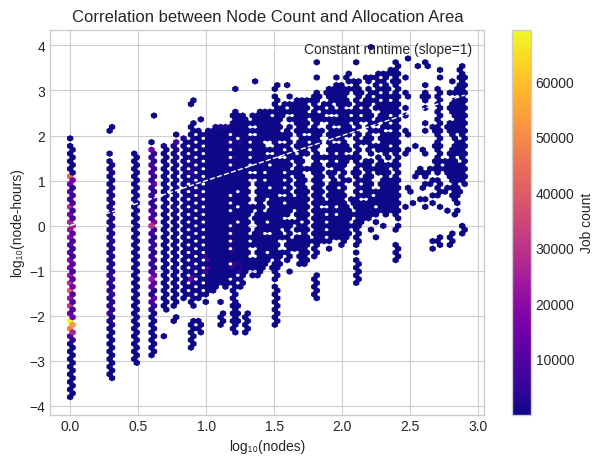

In [45]:
import matplotlib.pyplot as plt
import numpy as np

valid = (alloc_df["num_nodes"] > 0) & (alloc_df["runtime_hours"] > 0)
dfv = alloc_df.loc[valid, ["num_nodes", "runtime_hours"]].copy()
dfv["node_hours"] = dfv["num_nodes"] * dfv["runtime_hours"]

# --- Plot node vs area in log space ---
fig, ax = plt.subplots(figsize=(7,5))
hb = ax.hexbin(
    np.log10(dfv["num_nodes"]),
    np.log10(dfv["node_hours"]),
    gridsize=80, cmap="plasma", mincnt=1
)
cb = plt.colorbar(hb, ax=ax)
cb.set_label("Job count")

ax.set_xlabel("log₁₀(nodes)")
ax.set_ylabel("log₁₀(node-hours)")
ax.set_title("Correlation between Node Count and Allocation Area")

# Optionally add reference line (slope = 1)
x = np.linspace(dfv["num_nodes"].apply(np.log10).min(), dfv["num_nodes"].apply(np.log10).max(), 100)
ax.plot(x, x, color="white", linestyle="--", linewidth=1.0, label="Constant runtime (slope=1)")
ax.legend()

plt.show()


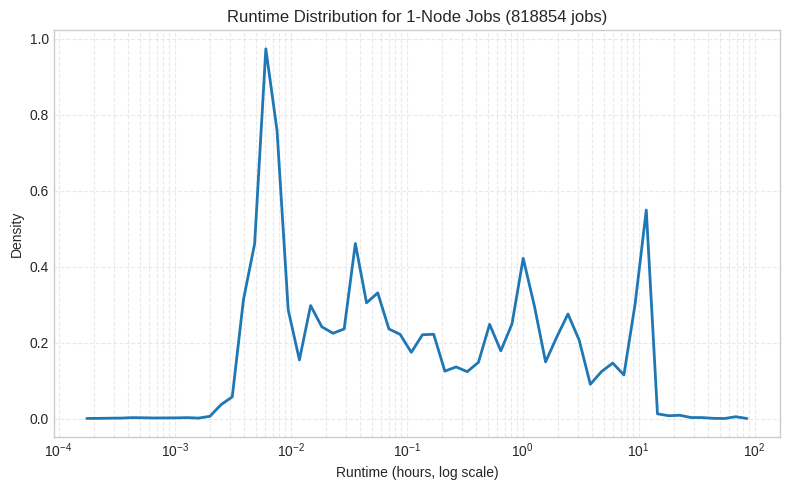

In [101]:
import numpy as np
import matplotlib.pyplot as plt

def plot_runtime_distribution(alloc_df, node_count, bins=60, logx=True):
    """
    Plot runtime distribution for jobs with a specific node count.
    """
    df = alloc_df[(alloc_df["num_nodes"] == node_count) &
                  (alloc_df["runtime_hours"] > 0)].copy()
    if df.empty:
        print(f"No jobs found with {node_count} nodes.")
        return

    runtimes = df["runtime_hours"].to_numpy()
    log_r = np.log10(runtimes)

    fig, ax = plt.subplots(figsize=(8,5))

    # Histogram as line plot (normalized)
    hist, edges = np.histogram(log_r, bins=bins, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    ax.plot(10**centers, hist, color="tab:blue", lw=2)

    # Log x-axis so hour scale is readable
    if logx:
        ax.set_xscale("log")

    ax.set_xlabel("Runtime (hours, log scale)")
    ax.set_ylabel("Density")
    ax.set_title(f"Runtime Distribution for {node_count}-Node Jobs "
                 f"({len(runtimes)} jobs)")
    ax.grid(True, which="both", ls="--", alpha=0.4)
    plt.tight_layout()
    plt.show()
plot_runtime_distribution(alloc_df, 1)


/home/j/Desktop/flux/flux_env/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


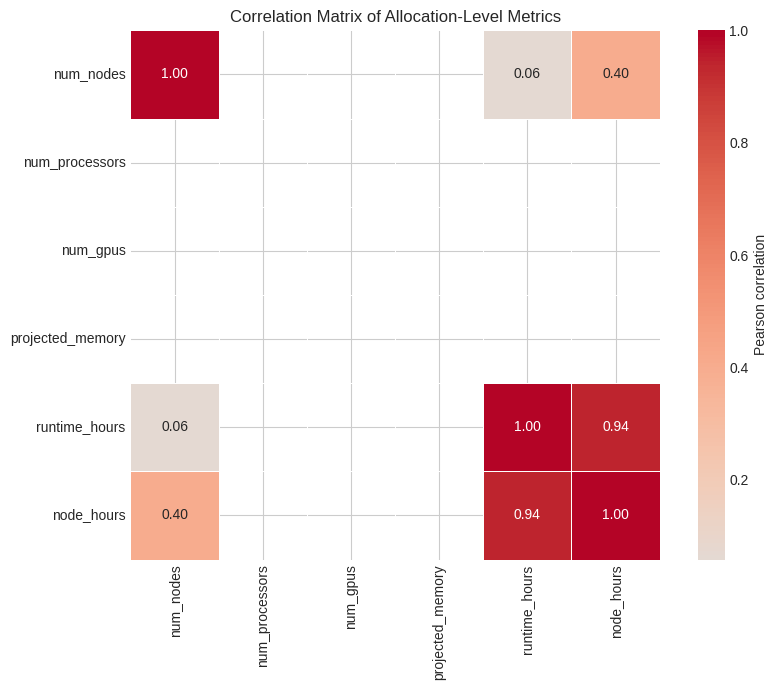

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_allocation_correlation(alloc_df, log_scale=True, figsize=(9,7)):
    """
    Plot correlation matrix for core numeric job metrics in the allocation table.

    Parameters
    ----------
    alloc_df : pd.DataFrame
        Must include numeric fields like num_nodes, num_processors, num_gpus,
        projected_memory, runtime_hours, node_hours, time_limit (if available).
    log_scale : bool
        If True, apply log10 transform to wide-range metrics before correlating.
    """
    # Select relevant numeric columns
    cols = [
        "num_nodes", "num_processors", "num_gpus",
        "projected_memory", "runtime_hours", "node_hours"
    ]
    cols = [c for c in cols if c in alloc_df.columns]

    df = alloc_df[cols].copy()

    # Log-transform skewed columns so large jobs don’t dominate correlation
    if log_scale:
        for c in ["num_nodes", "runtime_hours", "node_hours"]:
            if c in df:
                df[c] = np.log10(df[c].replace(0, np.nan))

    # Drop rows with NaN after transforms
    df = df.dropna()

    # Compute Pearson correlation matrix
    corr = df.corr(method="pearson")

    # --- Plot ---
    plt.figure(figsize=figsize)
    sns.heatmap(
        corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
        linewidths=0.6, square=True, cbar_kws={"label": "Pearson correlation"}
    )
    plt.title("Correlation Matrix of Allocation-Level Metrics")
    plt.tight_layout()
    plt.show()

    return corr
corr = plot_allocation_correlation(alloc_df)


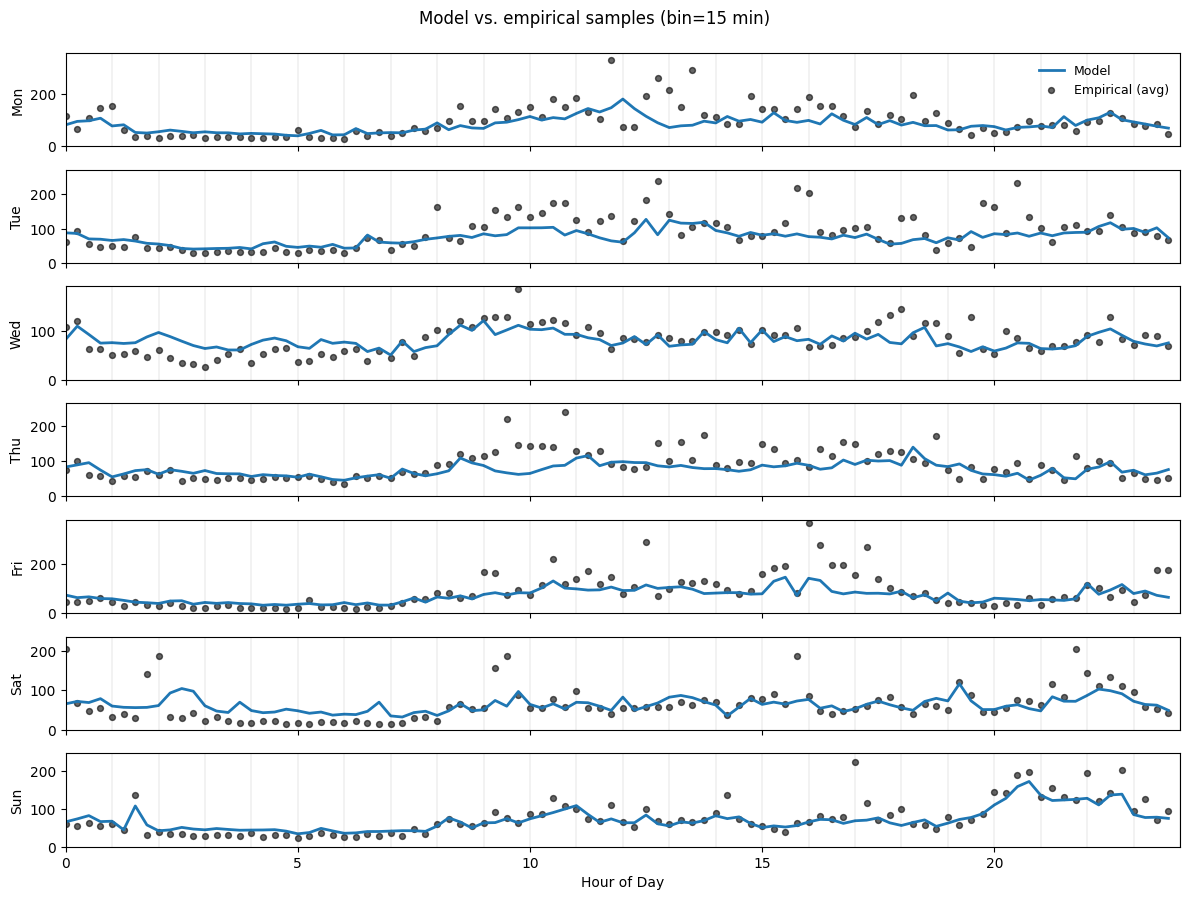

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _build_empirical_rate(df, time_col: str, bin_minutes: int):
    """Return a 7 x bins_per_day matrix of empirical jobs/hour averaged over occurrences
    of each weekday in the covered span (including zeros when a weekday occurred)."""
    t = pd.to_datetime(df[time_col], errors="coerce")
    t = t.dropna()
    if t.empty:
        raise ValueError("No valid timestamps in real data.")
    df = pd.DataFrame({time_col: t})
    df["weekday"] = df[time_col].dt.dayofweek
    mins = df[time_col].dt.hour * 60 + df[time_col].dt.minute
    bins_per_day = 1440 // bin_minutes
    df["bin_idx"] = (mins // bin_minutes).astype(int)

    counts = df.groupby(["weekday", "bin_idx"]).size().rename("count").reset_index()

    start_d = t.min().normalize()
    end_d   = t.max().normalize()
    all_days = pd.date_range(start_d, end_d, freq="D")
    weekday_occ = pd.Series(all_days.dayofweek).value_counts().reindex(range(7), fill_value=0)

    # full grid so zeros are explicit
    grid = pd.MultiIndex.from_product([range(7), range(bins_per_day)],
                                      names=["weekday","bin_idx"]).to_frame(index=False)
    counts_full = grid.merge(counts, on=["weekday","bin_idx"], how="left").fillna({"count":0})
    counts_full["occurs"] = counts_full["weekday"].map(weekday_occ).replace(0, np.nan)

    bin_hours = bin_minutes / 60.0
    rate = (counts_full["count"] / (counts_full["occurs"] * bin_hours)).fillna(0.0)
    rate_df = counts_full.assign(rate=rate).pivot(index="weekday", columns="bin_idx", values="rate")
    # 7 x B matrix
    B = bins_per_day
    mat = np.zeros((7, B), dtype=float)
    for w in range(7):
        if w in rate_df.index:
            mat[w, :] = rate_df.loc[w].to_numpy()
    return mat  # jobs/hour


def plot_weekly_model_vs_real(
    real_df: pd.DataFrame,
    model_npz_path: str,
    time_col: str = "job_submit_time",
    figsize=(12, 9),
    line_color="tab:blue",
    dot_color="black",
    alpha_dots=0.6,
    show_band=True,
    band_alpha=0.18,
):
    """Overlay model weekly rate (line) vs. real empirical rate (dots) per weekday.

    If the model file contains k_shape (over-dispersion) and p_zero (zero inflation),
    plot a ±2σ ZINB band around the model mean.
    """
    z = np.load(model_npz_path, allow_pickle=True)
    rate_model = z["rate"]              # shape (7, B), jobs/hour
    bin_minutes = int(z["bin_minutes"][0])
    B = rate_model.shape[1]
    # Optional extras for the uncertainty band
    k_mat = z["k_shape"] if "k_shape" in z.files else None
    p0_mat = z["p_zero"] if "p_zero" in z.files else None
    have_band = show_band and (k_mat is not None) and (p0_mat is not None)

    # empirical rate at same resolution
    rate_real = _build_empirical_rate(real_df, time_col, bin_minutes)  # (7, B)

    hours = np.linspace(0, 24, B, endpoint=False)  # bin starts in hours
    bin_hours = bin_minutes / 60.0

    # helper for ZINB band (mean is already the model rate per hour)
    def zinb_band(rate_per_hr_row, k_row, p0_row):
        """Return (lower, upper) arrays for ±2 std of rate/hour under ZINB."""
        # model stores overall mean per hour (including zeros):
        m_rate = rate_per_hr_row                     # (B,)
        m_bin = m_rate * bin_hours                   # mean count per bin overall

        p0 = np.clip(p0_row, 0.0, 0.999999)
        k  = np.where((k_row <= 0) | ~np.isfinite(k_row), 1e6, k_row)

        # Solve for NB component mean per bin: m_bin = (1-p0) * mu_nb  -> mu_nb = m_bin/(1-p0)
        mu_nb = np.divide(m_bin, (1.0 - p0), out=np.zeros_like(m_bin), where=(1.0 - p0) > 1e-9)

        # NB variance per bin: var_nb = mu_nb + mu_nb^2 / k
        var_nb = mu_nb + (mu_nb**2) / k

        # Mixture variance per bin: Var = (1-p0)*(Var_NB + mu_nb^2) - m_bin^2 + m_bin^2
        # Simpler closed form:
        # Var = (1-p0)*mu_nb + mu_nb^2*((1-p0)/k + p0*(1-p0))
        var_bin = (1.0 - p0) * mu_nb + (mu_nb**2) * ((1.0 - p0)/k + p0*(1.0 - p0))

        # Convert to rate/hour band
        std_rate = np.sqrt(np.maximum(var_bin, 0.0)) / bin_hours
        lo = np.clip(m_rate - 2.0 * std_rate, 0.0, None)
        hi = m_rate + 2.0 * std_rate
        return lo, hi

    # plot
    fig, axes = plt.subplots(7, 1, figsize=figsize, sharex=True)
    day_names = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

    for w in range(7):
        ax = axes[w]
        y_model = rate_model[w]
        y_real  = rate_real[w]

        if have_band:
            lo, hi = zinb_band(y_model, k_mat[w], p0_mat[w])
            ax.fill_between(hours, lo, hi, color=line_color, alpha=band_alpha, linewidth=0, label="±2σ (ZINB)")

        ax.plot(hours, y_model, color=line_color, lw=2.0, label="Model")
        ax.scatter(hours, y_real, s=18, color=dot_color, alpha=alpha_dots, label="Empirical (avg)")

        ax.set_ylabel(day_names[w])
        ax.set_xlim(0, 24)
        # light hour guides
        for x in range(0, 25, 1):
            ax.axvline(x, color="k", lw=0.3, alpha=0.25)

        # nice y-limit
        ymax = max(np.percentile(y_model, 99.5), np.percentile(y_real, 99.5), 1.0)
        ax.set_ylim(0, ymax * 1.15)

        if w == 0:
            # only show legend once if band present
            handles, labels = ax.get_legend_handles_labels()
            # remove duplicates
            seen = set(); H, L = [], []
            for h, l in zip(handles, labels):
                if l not in seen:
                    H.append(h); L.append(l); seen.add(l)
            ax.legend(H, L, loc="upper right", fontsize=9, frameon=False)

    axes[-1].set_xlabel("Hour of Day")
    fig.suptitle(f"Model vs. empirical samples (bin={bin_minutes} min)", y=0.995)
    plt.tight_layout()
    plt.show()

plot_weekly_model_vs_real(alloc_df, "weekly_rate_15m.npz")